# Exploring PyPSA-Zambia

This notebook guides you through the **PyPSA-Zambia** energy system model — an open-source power system model of Zambia built with [PyPSA](https://pypsa.org/) and the [PyPSA-Earth](https://pypsa-earth.readthedocs.io/) workflow.
---

## Learning Objectives

By the end of this notebook you will be able to:

1. Load and inspect a PyPSA network from a `.nc` file.
2. Visualise the **network topology** (buses, lines, links) on a map.
3. Extract and plot **installed generation and transmission capacities** by technology.
4. Plot **per-plant dispatch** time series and identify which plants set the system price.
5. Analyse **hydro inflow** .
6. Compute **transmission line loading** and identify congested corridors.
7. Check **cross-border power flows** on international interconnectors.
8. Interpret **capacity-expansion results**: which technologies are built, at what cost, and why.
9. Calculate **system-level CO₂ emissions** per technology.
10. Construct an **energy balance** and verify that supply equals demand.

## Setup

### Paths

Set the path to your local `pypsa-zambia` results folder below. If you are running this notebook from within the `pypsa-zambia` repository, the default relative path should work.

In [388]:
scenario_name = "cap_exp_zambia_2025"

scenario_subpath = scenario_name if scenario_name else ""
PARENT = "../"
solar_path  = f"{PARENT}resources/{scenario_name}/renewable_profiles/profile_solar.nc"
onwind_path = f"{PARENT}resources/{scenario_name}/renewable_profiles/profile_onwind.nc"


### Import Packages

In [389]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
import xarray as xr
import cartopy.crs as ccrs
import cartopy
import geopandas as gpd
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import yaml
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch



set a clean plot style

In [390]:


plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)

CARRIER_COLORS = {
    "hydro":         "#3182bd",
    "ror":           "#6baed6",
    "solar":         "#fd8d3c",
    "onwind":        "#74c476",
    "biomass":       "#756bb1",
    "coal":          "#636363",
    "oil":           "#d62728",
    "load shedding": "#e6550d",
    "export":        "#9ecae1",
}



### Load the Network

In [391]:
network_path = os.path.join(
    "../", "results", scenario_subpath, "networks", "elec_s_10_ec_lcopt_3h.nc"
)
n = pypsa.Network(network_path)

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_3h.nc has buses, carriers, generators, lines, line_types, links, loads, storage_units


## 1.1 Network Topology

The Zambian grid is modelled as a set of **buses** (substations) connected by **lines** (AC transmission) and **links** (DC or cross-border interconnectors). Each bus aggregates local demand and any generators or storage units attached to it.

/home/albert/miniconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x76b91a1b91d0>,
 <matplotlib.collections.LineCollection at 0x76b919f296d0>)

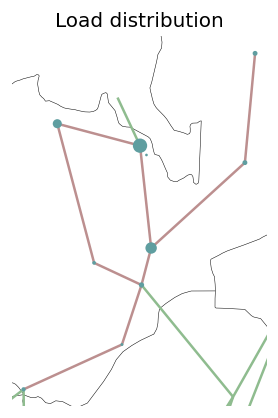

In [392]:
fig, ax = plt.subplots(
    1,
    1,
    subplot_kw={"projection": ccrs.EqualEarth()},
)

load_distribution = n.loads_t.p_set.loc[n.snapshots[0]].groupby(n.loads.bus).sum()
n.plot(bus_sizes=load_distribution / 20000, ax=ax, title="Load distribution")


## 1.2 Generation Installed Capacities

Before examining how plants operate, we need to understand *what* is installed. Installed capacity is measured in **MW** and stored in the `p_nom` column of `n.generators` (for non-storage technologies) and `n.storage_units` (for reservoir hydro).

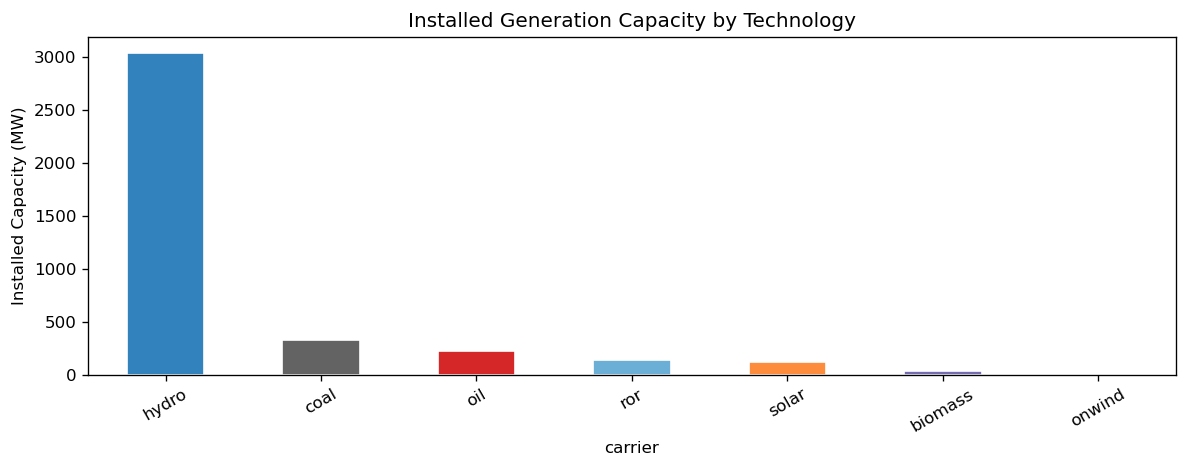

carrier
hydro      3033.0
coal        330.0
oil         229.6
ror         138.8
solar       122.0
biomass      40.0
onwind        0.0

Total: 3893 MW


In [393]:
# generators (excludes load shedding and virtual export generator)
gen_cap = (
    n.generators
    .query("carrier not in ['load shedding', 'export']")
    .groupby("carrier").p_nom.sum()
)

# reservoir hydro lives in storage_units
sto_cap = n.storage_units.groupby("carrier").p_nom.sum()

installed = pd.concat([gen_cap, sto_cap]).sort_values(ascending=False)

fig, ax = plt.subplots()
colors = [CARRIER_COLORS.get(c, "#aaa") for c in installed.index]
installed.plot.bar(ax=ax, color=colors, edgecolor="white")
ax.set_ylabel("Installed Capacity (MW)")
ax.set_title("Installed Generation Capacity by Technology")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print(installed.to_string())
print(f"\nTotal: {installed.sum():.0f} MW")

## 1.3 Transmission Installed Capacities

Transmission capacity determines how much power can flow between different parts of the country. Lines are characterised by their **thermal rating** (`s_nom`, in MVA), while links use a directional power limit (`p_nom`, in MW).

In [394]:
n.lines.columns

Index(['num_parallel', 'v_nom', 'bus0', 'bus1', 'length', 'dc', 'geometry',
       'carrier', 'type', 's_max_pu', 's_nom', 'underwater_fraction',
       'capital_cost', 'i_nom', 's_nom_extendable', 's_nom_min', 'x', 'r', 'b',
       'x_pu_eff', 'r_pu_eff', 's_nom_opt', 'g', 's_nom_mod', 's_nom_max',
       'build_year', 'lifetime', 'terrain_factor', 'v_ang_min', 'v_ang_max',
       'sub_network', 'x_pu', 'r_pu', 'g_pu', 'b_pu'],
      dtype='object')

In [395]:
n.lines.head(5)

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,carrier,type,s_max_pu,...,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
Line,,,,,,,,,,,,,,,,,,,,,
0,1.117500,330.0,ZM0 0,ZM0 5,311.042343,False,MULTILINESTRING ((31.159214099999954 -10.23079...,AC,ACSR Bison 330.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1,2.000000,330.0,ZM0 0,ZM0 6,412.741019,False,"MULTILINESTRING ((28.5722 -14.5945, 28.5728081...",AC,ACSR Bison 330.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
2,3.313333,330.0,ZM0 1,ZM0 6,109.621418,False,MULTILINESTRING ((28.514038399999972 -15.47108...,AC,ACSR Bison 330.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
3,4.000000,330.0,ZM0 1,ZM0 7,181.272002,False,"MULTILINESTRING ((28.1514 -15.7438, 28.1624177...",AC,ACSR Bison 330.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
4,2.000000,330.0,ZM0 1,ZM0 8,189.779939,False,"MULTILINESTRING ((27.0165 -15.0659, 27.0174300...",AC,ACSR Bison 330.0,0.7,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


In [396]:
n.lines.s_nom

Line
0     510.989629
1     914.522826
2    1515.059482
3    1829.045653
4     914.522826
5     457.261413
6    1829.045653
7     914.522826
8     457.261413
Name: s_nom, dtype: float64

In [397]:
n.links

,bus0,bus1,carrier,p_nom,p_min_pu,marginal_cost,p_nom_opt,type,efficiency,build_year,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,
Kariba-330kV,ZM0 1,ZW,AC,1400.0,-1.0,0.009920,1400.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
CEC-Copperbelt-220kV,ZM0 2,CD,AC,600.0,-1.0,0.010793,600.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Sesheke-220kV,ZM0 4,nan,AC,300.0,-1.0,0.009380,300.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Kazungula-66kV,ZM0 4,BW,AC,70.0,-1.0,0.009412,70.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Matimba-Insukamini-400kV,ZW,ZA,AC,500.0,-1.0,0.010034,500.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Songo-Bindura-330kV,ZW,MZ,AC,500.0,-1.0,0.009139,500.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
CahoraBassa-HVDC-533kV,MZ,ZA,AC,2000.0,-1.0,0.010517,2000.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Eskom-BPC-220kV,ZA,BW,AC,650.0,-1.0,0.010609,650.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
Caprivi-HVDC-350kV,ZA,nan,AC,300.0,-1.0,0.010784,300.0,,1.0,0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


## 1.4 Per-Plant Dispatch

The dispatch model outputs the power output of every generator at every timestep in `n.generators_t.p`. A **stacked area chart** of generation grouped by carrier reveals the *merit order*: cheapest plants run first (hydro, solar, wind), while expensive thermal plants (oil, coal) cover residual demand.

/tmp/ipykernel_20123/156974389.py:49: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  n.generators_t.p.groupby(n.generators.carrier, axis=1)


(<Figure size 720x360 with 1 Axes>, <Axes: xlabel='snapshot', ylabel='GW'>)

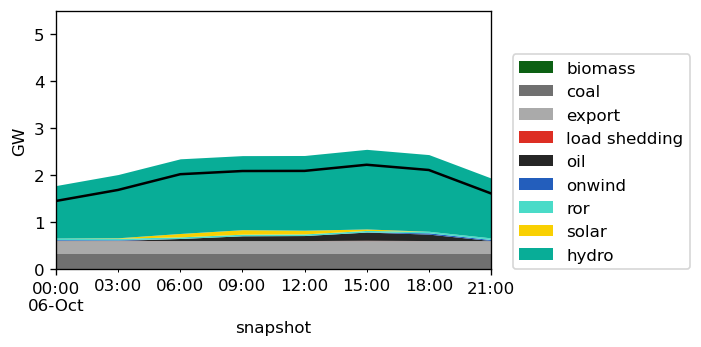

In [398]:
def plot_dispatch(n, time="2013-10-09"):
    p_by_carrier = (
        n.generators_t.p.groupby(n.generators.carrier, axis=1)
        .sum()
        .div(1e3)
    )

    if not n.storage_units.empty:
        sto = (
            n.storage_units_t.p.T
            .groupby(n.storage_units.carrier)
            .sum()
            .T
            .div(1e3)
        )
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    fig, ax = plt.subplots(figsize=(6, 3))
    color = p_by_carrier.columns.map(n.carriers.color)

    p_by_carrier.where(p_by_carrier > 0).loc[time].plot.area(
        ax=ax,
        linewidth=0,
        color=color,
    )

    charge = (
        p_by_carrier.where(p_by_carrier < 0)
        .dropna(how="all", axis=1)
        .loc[time]
    )
    if not charge.empty:
        charge.plot.area(
            ax=ax,
            linewidth=0,
            color=charge.columns.map(n.carriers.color),
        )

    n.loads_t.p_set.sum(axis=1).loc[time].div(1e3).plot(ax=ax, c="k")

    plt.legend(loc=(1.05, 0))
    ax.set_ylabel("GW")
    ax.set_ylim(0, 5.5)
    plt.tight_layout()

    return fig, ax
def plot_dispatch(n, time="2013-10-06"):
    p_by_carrier = (
        n.generators_t.p.groupby(n.generators.carrier, axis=1)
        .sum()
        .div(1e3)
    )

    if not n.storage_units.empty:
        sto = (
            n.storage_units_t.p.T
            .groupby(n.storage_units.carrier)
            .sum()
            .T
            .div(1e3)
        )
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    fig, ax = plt.subplots(figsize=(6, 3))
    # safe color lookup with fallback for missing values
    colors = n.carriers.color.reindex(p_by_carrier.columns).fillna("#aaaaaa").values

    p_by_carrier.where(p_by_carrier > 0).loc[time].plot.area(
        ax=ax,
        linewidth=0,
        color=colors,
    )

    charge = (
        p_by_carrier.where(p_by_carrier < 0)
        .dropna(how="all", axis=1)
        .loc[time]
    )
    if not charge.empty:
        charge_colors = n.carriers.color.reindex(charge.columns).fillna("#aaaaaa").values
        charge.plot.area(
            ax=ax,
            linewidth=0,
            color=charge_colors,
        )

    n.loads_t.p_set.sum(axis=1).loc[time].div(1e3).plot(ax=ax, c="k")

    plt.legend(loc=(1.05, 0))
    ax.set_ylabel("GW")
    ax.set_ylim(0, 5.5)
    plt.tight_layout()

    return fig, ax

plot_dispatch(n)

## 1.5 Hydro Inflow per Plant

For reservoir hydro, the available water (inflow) constrains how much energy can be generated. Inflow is stored in `n.storage_units_t.inflow` (in MW equivalent). Zambia's largest plant, **Kariba**, is shared with Zimbabwe and is heavily affected by seasonal and multi-year rainfall variability.

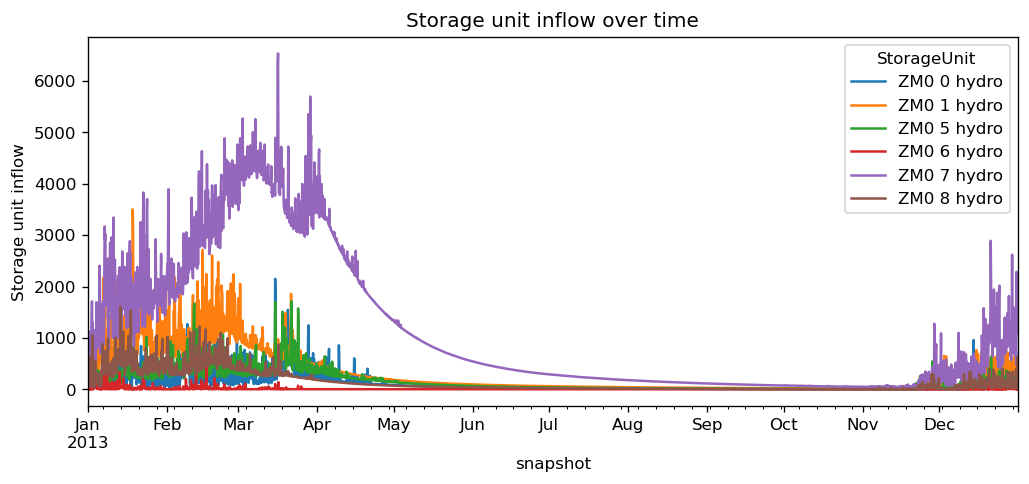

In [399]:
n.storage_units_t.inflow.plot()
plt.ylabel("Storage unit inflow")
plt.title("Storage unit inflow over time")
plt.show()

## 1.6 Electricity Generation



### 1.6.1 Electricity Generated By Power Plants

In [400]:
valid_generators = n.generators.query(
    "carrier != 'load shedding' and carrier != 'export'"
).index

gen_energy_by_carrier_gwh = (
    n.generators_t.p.mul(n.snapshot_weightings.generators, axis=0)
    .groupby(n.generators.loc[valid_generators, "carrier"], axis=1)
    .sum()
    .sum()
    / 1e6
)

print(gen_energy_by_carrier_gwh)

carrier
biomass    0.000000
coal       2.890800
oil        0.296410
onwind     0.064794
ror        0.838836
solar      0.294066
dtype: float64


/tmp/ipykernel_20123/1922211975.py:7: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  .groupby(n.generators.loc[valid_generators, "carrier"], axis=1)


In [401]:
print(f"{gen_energy_by_carrier_gwh.sum().round(2)} TWh")

4.38 TWh


### 1.6.2 Electricity Generated By Reservoir Hydro Power Plants

In [402]:
hydro_generation_twh = (
    n.storage_units_t.p.mul(n.snapshot_weightings.generators, axis=0).sum().sum() / 1e6
)
print(f"{hydro_generation_twh.round(2)} TWh")

12.46 TWh


Total Electricity Generated 

In [403]:
print(
    f" Total Energy Generated: {float(hydro_generation_twh.round(2)) + float(gen_energy_by_carrier_gwh.sum().round(2))} TWh"
)

 Total Energy Generated: 16.84 TWh


## 1.7 Power Flows in Transmission Lines

The **loading factor** of a line is the fraction of its rated capacity that is actually used:  
$$\text{loading} = \frac{|P_0|}{s_{\text{nom}}}$$

Lines with loading close to 100 % are **congested** — they limit the transfer of cheap generation to where it is needed, raising the system cost.

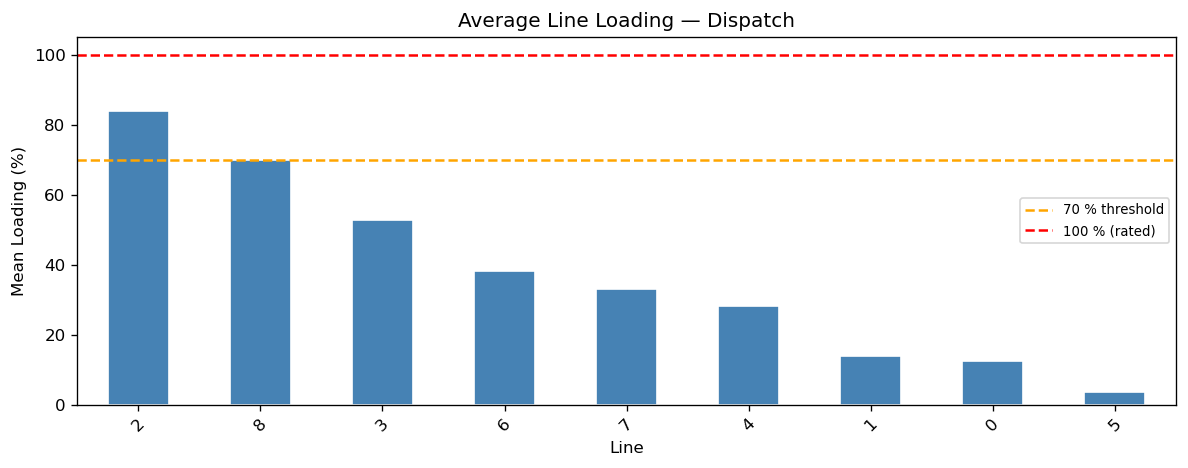

In [404]:
# mean absolute loading per line
mean_loading = (
    n.lines_t.p0.abs()
    .mean()
    .div(n.lines.s_nom)
    .mul(100)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
mean_loading.plot.bar(ax=ax, color="steelblue", edgecolor="white")
ax.axhline(70, color="orange", linestyle="--", label="70 % threshold")
ax.axhline(100, color="red", linestyle="--", label="100 % (rated)")
ax.set_ylabel("Mean Loading (%)")
ax.set_title("Average Line Loading — Dispatch")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 1.8 Power Flows in Interconnectors

Zambia is connected to several neighbouring countries. Positive flow (from `bus0` to `bus1`) means **export**; negative means **import**. These flows affect both system security and regional energy trade revenues.

In [405]:
flows_gwh = n.links_t.p0.mul(n.snapshot_weightings.objective, axis=0).sum() / 1e3

In [406]:
imports = 0.0
exports = 0.0

for link in n.links.index:
    bus0 = n.links.loc[link, "bus0"]
    bus1 = n.links.loc[link, "bus1"]

    c0 = n.buses.loc[bus0, "country"]
    c1 = n.buses.loc[bus1, "country"]

    # only border links touching Zambia
    if c0 == "ZM":
        flow = flows_gwh[link]
        exports += max(flow, 0)
        imports += max(-flow, 0)

    elif c1 == "ZM":
        flow = flows_gwh[link]
        imports += max(flow, 0)
        exports += max(-flow, 0)

print("Imports (GWh):", imports)
print("Exports (GWh):", exports)

Imports (GWh): 3221.468354386835
Exports (GWh): 3628.468354383226


## 1.9 Electricity Demand 

In [407]:
demand = (
    n.loads_t.p_set.multiply(n.snapshot_weightings.objective, axis=0).sum().sum() / 1e6
)

In [408]:
print(f"{demand.round(2)} TWh")

16.47 TWh


## 1.9 System Marginal Cost

After solving, PyPSA records the **nodal marginal price** (`n.buses_t.marginal_price`) at every bus and timestep. This is the dual variable of the power-balance constraint — the cost of supplying one additional MWh at that node and time, also called the **locational marginal price (LMP)**.

$$\lambda_{b,t} \; [\text{€/MWh}] \quad \Leftrightarrow \quad \frac{\lambda_{b,t}}{1000} \; [\text{€/kWh}]$$

Key insights from marginal prices:
- **Low prices** occur when cheap hydro or renewables are setting the margin.
- **Price spikes** occur when expensive oil peakers are the marginal unit (usually during dry-season low water).
- **Price differences between buses** reveal congestion on the transmission network.

---
# Part 2: Investment Planning

The **capacity-expansion model** adds a planning dimension: instead of fixing all capacities, it is free to *invest* in new generation and transmission to minimise the total system cost over the planning horizon. We use the 2025 scenario here.

## Optimized Capacities

In [409]:
n.statistics.optimal_capacity()

component    carrier        
Link         Ac                 6942.00000
Line         Ac                 9802.43974
Generator    Biomass              40.00000
             Coal                330.00000
             Load shedding      2733.84041
             Oil                 229.60000
             Onshore Wind        175.18534
             Run of River        138.80000
             Solar               405.54252
             export              281.50685
StorageUnit  Reservoir & Dam    3033.00000
dtype: float64

In [410]:
n.statistics.expanded_capacity()

component    carrier        
Link         Ac                   0.00000
Line         Ac                 460.20802
Generator    Biomass              0.00000
             Coal                 0.00000
             Load shedding        0.00000
             Oil                  0.00000
             Onshore Wind       175.18534
             Run of River         0.00000
             Solar              283.54252
             export               0.00000
StorageUnit  Reservoir & Dam      0.00000
dtype: float64

Plot

ValueError: Invalid RGBA argument: nan

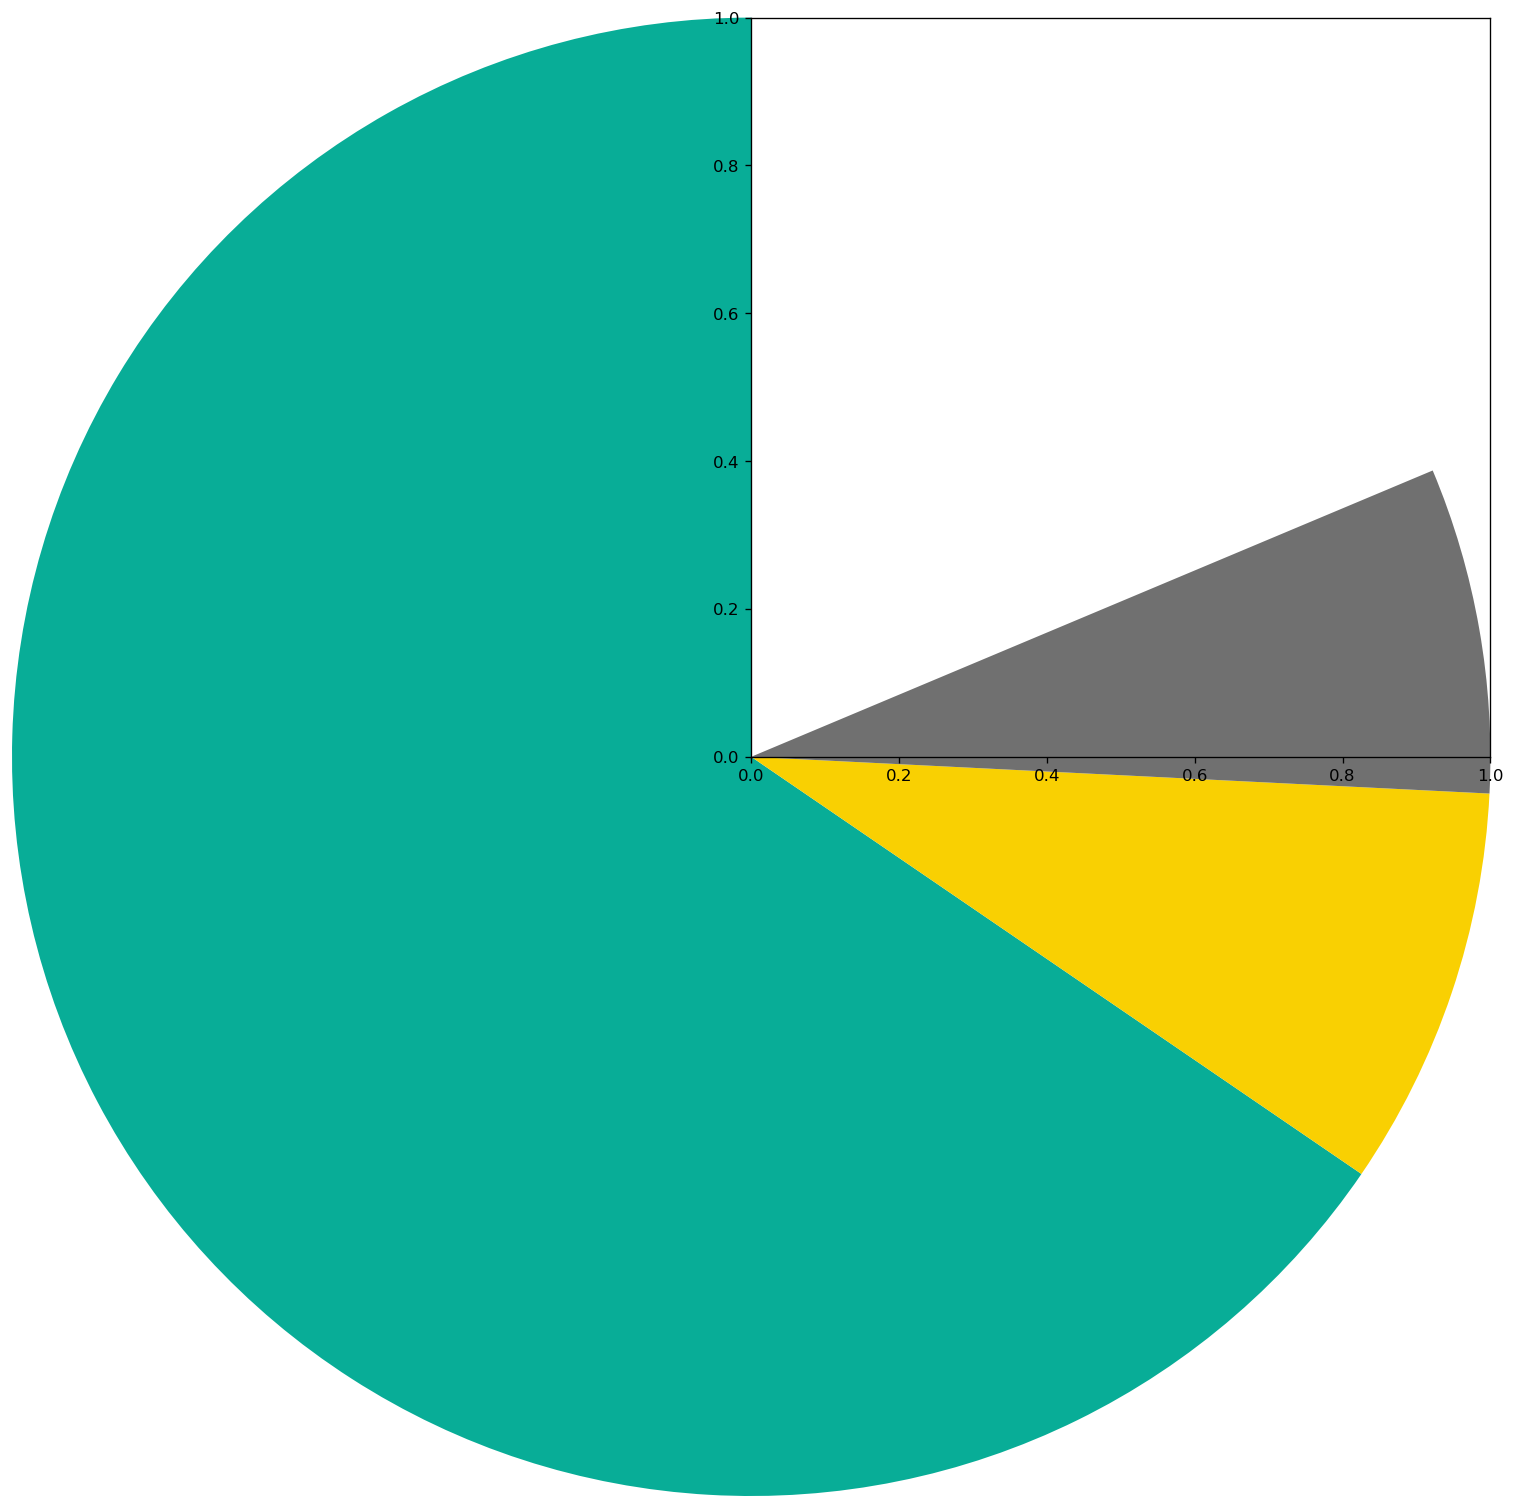

In [ ]:
import pandas as pd


# --- Generators (exclude load shedding) ---
generator_capacity_by_carrier = (
    n.generators[~n.generators.carrier.str.contains("load", case=False)]
    .groupby("carrier")
    .p_nom_opt.sum()
    .div(1e3)
)

# --- Storage units (e.g. hydro reservoirs) ---
storage_capacity_by_carrier = (
    n.storage_units.groupby("carrier")
    .p_nom_opt.sum()
    .div(1e3)
)

# --- Combine, deduplicate, filter zeros ---
capacity_by_carrier = (
    pd.concat([generator_capacity_by_carrier, storage_capacity_by_carrier])
    .groupby(level=0).sum()
    .sort_values(ascending=False)
)
capacity_by_carrier = capacity_by_carrier[capacity_by_carrier > 0]

# --- Colors ---
colors = (
    n.carriers[n.carriers.index.isin(capacity_by_carrier.index)]
    .color.reindex(capacity_by_carrier.index)
)

labels = [
    f"{c} ({v:.1f} GW, {100 * v / capacity_by_carrier.sum():.1f}%)"
    for c, v in zip(capacity_by_carrier.index, capacity_by_carrier.values)
]

fig, ax = plt.subplots(figsize=(8, 8))

# ensure colors contains valid matplotlib color strings (no NaN)
if hasattr(colors, "fillna"):
    colors = colors.fillna("#aaaaaa").tolist()
else:
    colors = [c if pd.notna(c) else "#aaaaaa" for c in colors]
wedges, _ = ax.pie(
    capacity_by_carrier,
    labels=None,
    startangle=90,
    colors=colors,
)
ax.legend(wedges, labels, loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
ax.set_title("Optimised Capacity by Carrier (GW)")
plt.show()

## 2.1 Renewable Resource Potential

Before investing, the model needs to know *how much* renewable energy is available at each location. This is captured by **capacity factor profiles** (`p_max_pu`) — a value between 0 and 1 representing the fraction of rated capacity available at each timestep.

Plot Renewable resource potential maps

In [ ]:
solar = xr.open_dataset(solar_path)
wind  = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, regions_file, cmap, title=None, filename=None):
    if carrier in n.generators.carrier.values:
        cap = n.generators[n.generators.carrier == carrier].groupby("bus").p_nom_max.sum()
    elif carrier in n.storage_units.carrier.values:
        cap = n.storage_units[n.storage_units.carrier == carrier].groupby("bus").p_nom.sum()
    else:
        raise ValueError(f"Carrier '{carrier}' not found in generators or storage units.")

    br = gpd.read_file(regions_file).set_index("name")
    br_area = br.to_crs("ESRI:54009").geometry.area * 1e-6
    br["density"] = cap.reindex(br.index) / br_area

    bounds = br.total_bounds
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.PlateCarree()})
    br.plot(
        ax=ax,
        column="density",
        transform=ccrs.PlateCarree(),
        linewidth=0.5,
        edgecolor="k",
        cmap=cmap,
        legend=True,
        legend_kwds={"label": "MW/km²", "shrink": 0.6},
        missing_kwds={"color": "lightgrey"},
    )
    ax.add_feature(cartopy.feature.BORDERS.with_scale("10m"), linewidth=0.5)
    ax.set_extent([bounds[0]-0.5, bounds[2]+0.5, bounds[1]-0.5, bounds[3]+0.5], crs=ccrs.PlateCarree())
    if title:
        ax.set_title(title, pad=10)
    if filename:
        plt.savefig(filename, bbox_inches="tight", dpi=150)
    plt.show()


def plot_biomass_circles(biomass_csv, gadm_file, title="Biomass potential by province (MW)", filename=None):
    """Plot biomass potential as proportional circles at province centroids."""
    fao = pd.read_csv(biomass_csv, index_col="province")
    gadm = gpd.read_file(gadm_file)

    # Province centroids in lon/lat
    centroids = gadm.set_index("NAME_1").geometry.to_crs("EPSG:4326").centroid
    fao["lon"] = centroids.reindex(fao.index).x
    fao["lat"] = centroids.reindex(fao.index).y

    bounds = gadm.total_bounds
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": ccrs.PlateCarree()})

    # Province background
    gadm.plot(ax=ax, facecolor="whitesmoke", edgecolor="grey",
              linewidth=0.5, transform=ccrs.PlateCarree())

    # Circles scaled by biomass_mw
    scale = 10  # km² per MW — increase to shrink circles
    scatter = ax.scatter(
        fao["lon"], fao["lat"],
        s=fao["biomass_mw"] / scale,
        color="#4caf50", alpha=0.7, edgecolors="darkgreen",
        linewidths=0.8, transform=ccrs.PlateCarree(), zorder=5,
    )

    # Province name + MW labels
    for province, row in fao.iterrows():
        if pd.notna(row["lon"]):
            ax.text(row["lon"], row["lat"] - 0.4, f"{province}\n{int(row['biomass_mw'])} MW",
                    ha="center", va="top", fontsize=7.5, transform=ccrs.PlateCarree(), zorder=6)

    # Size legend
    for mw in [50, 100, 200]:
        ax.scatter([], [], s=mw / scale, color="#4caf50", alpha=0.7,
                   edgecolors="darkgreen", linewidths=0.8, label=f"{mw} MW")
    ax.legend(title="Potential", frameon=False, loc="lower right", fontsize=8)

    ax.add_feature(cartopy.feature.BORDERS.with_scale("10m"), linewidth=0.5)
    ax.set_extent([bounds[0]-0.5, bounds[2]+0.5, bounds[1]-0.5, bounds[3]+0.5], crs=ccrs.PlateCarree())
    ax.set_title(title, pad=10)
    if filename:
        plt.savefig(filename, bbox_inches="tight", dpi=150)
    plt.show()


clusters = "10"
regions_onshore = f"{PARENT}resources/{scenario_name}/bus_regions/regions_onshore_elec_s_{clusters}.geojson"
gadm_file       = f"{PARENT}resources/{scenario_name}/shapes/gadm_shapes.geojson"
biomass_csv     = f"{PARENT}data/biomass_data.csv"

plot_voronoi(n, "solar",  regions_onshore, "YlOrRd", title="Solar potential density (MW/km²)")
plot_voronoi(n, "onwind", regions_onshore, "Blues",  title="Onshore wind potential density (MW/km²)")
plot_voronoi(n, "hydro",  regions_onshore, "GnBu",   title="Hydro installed capacity density (MW/km²)")
plot_biomass_circles(biomass_csv, gadm_file)

## 2.2 Generator Optimised Capacities

After solving the optimisation, `p_nom_opt` holds the **optimal installed capacity** for each generator. For non-extendable plants this equals `p_nom` (the fixed capacity).

In [ ]:
n.generators.groupby("carrier").p_nom_opt.sum()

In [ ]:
n.statistics.expanded_capacity()

## 2.3 Line Optimised Capacities

Transmission lines can also be expanded in a capacity-expansion model.

In [ ]:
diff=n.lines.s_nom_opt.sum() - n.lines.s_nom.sum()
print(f'{diff.round(2)} MVA')

## 2.4 Cost per Technology (CAPEX + OPEX)

The total annualised cost of a technology has two components:

- **CAPEX** (`capital_cost`): the annualised investment cost in €/MW/year. Stored per generator in `n.generators.capital_cost`.
- **OPEX** (`marginal_cost`): the variable cost of generating one MWh in €/MWh. Stored in `n.generators.marginal_cost`.

Total cost per technology = CAPEX × capacity + OPEX × energy generated.

In [ ]:
n.statistics.expanded_capex()/1e6

## 2.5 Total System Cost

The **objective value** is the total annualised system cost minimised by the solver. We can break it down into the contributions from each generator to understand where costs come from.

In [ ]:
tsc = (
    pd.concat([n.statistics.expanded_capex(), n.statistics.opex()], axis=1).sum(axis=1).div(1e6)
)
tsc

In [ ]:
print(f"{tsc.sum().round(2)} mEUR/MW/year")

## 2.6 Emissions per Technology

Each carrier has a CO₂ intensity stored in `n.carriers.co2_emissions` (tonnes of CO₂ per MWh of fuel input, not output). Total emissions are:

$$E_{\text{carrier}} = \sum_t P_{g,t} \cdot w_t \cdot \frac{\text{co2\_emissions}_{\text{carrier}}}{\eta_g}$$

where $\eta_g$ is the generator efficiency and $w_t$ are snapshot weightings.

In [ ]:
emissions = (
 n.generators_t.p
/ n.generators.efficiency
* n.generators.carrier.map(n.carriers.co2_emissions)
) # t/h

total_emissions_mt = (n.snapshot_weightings.generators @ emissions.sum(axis=1)).sum() / 1e6
print(f"{total_emissions_mt:.3f} Mt CO₂/year")



## 2.7 Spatial Distribution of Power Plants and Lines

PyPSA buses carry geographic coordinates, so we can plot where generators are located and how they connect via the transmission network. Bus size reflects installed (or optimised) capacity.

In [ ]:
# --- Load shapes ---
gadm_shapes = gpd.read_file(f"../resources/{scenario_name}/shapes/gadm_shapes.geojson").set_index("GADM_ID")
regions_onshore = gpd.read_file(f"../resources/{scenario_name}/bus_regions/regions_onshore_elec_s.geojson").set_index("name")

# --- Optimised capacities by bus + carrier ---
skip = ["load shedding", "export", "import"]
gen = (
    n.generators[~n.generators.carrier.isin(skip)]
    .groupby(["bus", "carrier"])
    .p_nom_opt.sum()
)
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])
buses = buses[buses > 0.1]  # drop noise

# --- Scales ---
bus_scale = 6000      # MW per unit circle area — increase to shrink map circles
line_scale = 1500     # MW per unit line width
bus_sizes  = [100, 500, 1000]   # legend reference sizes (MW) — reduce to shrink legend circles
line_sizes = [500, 1000, 2000]

# --- Filter links to within-Zambia only ---
zm_buses = set(n.buses[n.buses.country == "ZM"].index)
valid_links = n.links[
    n.links.bus0.isin(zm_buses) &
    n.links.bus1.isin(zm_buses) &
    (n.links.p_nom_opt > 0)
]
links_backup = n.links
n.links = valid_links

plot_boundaries = regions_onshore.total_bounds[[0, 2, 1, 3]]


fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Background regions ---
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    aspect="equal",
)

with plt.rc_context({"patch.linewidth": 0.0}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.8,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        color_geomap=None,
        boundaries=plot_boundaries,
    )

n.links = links_backup

# --- Legends ---
legend_kw = {"loc": "upper left", "frameon": False}

add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s/1000:.0f} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1.02, 1.0), **legend_kw},
)
add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s} MW" for s in bus_sizes],
    legend_kw={"bbox_to_anchor": (1.02, 0.78), "labelspacing": 1.5, **legend_kw},
)

# Carrier colour patches — only carriers with capacity above threshold
min_mw = 50
colors_leg, labels_leg, seen = [], [], set()
for c in n.carriers.index:
    if c in skip:
        continue
    nice = n.carriers.loc[c, "nice_name"]
    color = n.carriers.loc[c, "color"]
    total = buses.xs(c, level="carrier").sum() if c in buses.index.get_level_values("carrier") else 0
    if nice not in seen and total > min_mw:
        seen.add(nice)
        colors_leg.append(color)
        labels_leg.append(f"{nice}  ({total/1000:.1f} GW)")

add_legend_patches(
    ax,
    colors_leg,
    labels_leg,
    legend_kw={"bbox_to_anchor": (1.02, 0.45), **legend_kw, "loc": "upper left"},
)

ax.set_title("Optimised installed capacity by carrier", fontsize=13, pad=10)
fig.tight_layout()
plt.show()



## 2.9 Energy Balance

A fundamental check: **total supply must equal total demand** (plus losses, exports, and curtailment). The energy balance is:

$$\text{Generation} + \text{Imports} = \text{Load} + \text{Exports} + \text{Curtailment} + \text{Load Shedding}$$

Any discrepancy indicates a modelling inconsistency.

In [ ]:


# --- Load config for colors and nice names ---
with open("../config.default.yaml") as f:
    cfg = yaml.safe_load(f)

# --- Energy balance grouped by carrier, converted to TWh ---
energy_balance = (
    n.statistics.energy_balance()
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns={"-": "Load"})
)
energy_balance = energy_balance.loc[:, (energy_balance != 0).any(axis=0)]

# --- Color lookup using nice_names as keys (energy_balance uses nice names) ---
tech_colors = {k.lower(): v for k, v in cfg["plotting"]["tech_colors"].items()}
nice_names_map = {v.lower(): v for v in cfg["plotting"]["nice_names"].values()}

def color_for(col):
    return tech_colors.get(col.lower(), "#9e9e9e")

# --- Order: top 10 by absolute value, rest → "Other" ---
top_n = 10
s = energy_balance.iloc[0]
ordered = s.reindex(s.abs().sort_values(ascending=False).index)
top_cols = ordered.index[:top_n].tolist()
other_cols = ordered.index[top_n:].tolist()

df_plot = energy_balance[top_cols].copy()
if other_cols:
    df_plot["Other"] = energy_balance[other_cols].sum(axis=1)

# Positives largest→smallest, negatives smallest→largest
pos = df_plot.iloc[0][df_plot.iloc[0] > 0].sort_values(ascending=False)
neg = df_plot.iloc[0][df_plot.iloc[0] < 0].sort_values(ascending=True)
df_plot = df_plot[list(pos.index) + list(neg.index)]

color_list = [color_for(c) if c != "Other" else "#cfcfcf" for c in df_plot.columns]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4.5))
df_plot.plot.barh(
    stacked=True, ax=ax, color=color_list, edgecolor="white", linewidth=0.6, width=0.6
)
ax.set_title("Energy Balance in TWh", pad=12)
ax.set_xlabel("TWh")
ax.set_yticklabels([""])
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.grid(axis="x", linestyle=":", linewidth=0.7, alpha=0.6)
ax.axvline(0, color="#444", linewidth=0.8)

# --- Legend ---
handles = [
    Patch(facecolor=color_list[i], edgecolor="white", linewidth=0.6, label=c)
    for i, c in enumerate(df_plot.columns)
]
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=4,
    frameon=False,
    fontsize=9,
)

# --- Annotate totals ---
vals = df_plot.iloc[0]
cum_pos = vals[vals > 0].sum()
cum_neg = vals[vals < 0].sum()
ax.text(cum_pos, 0, f"  +{int(round(cum_pos)):,}", va="center", ha="left", fontsize=9)
ax.text(cum_neg, 0, f"{int(round(cum_neg)):,}  ", va="center", ha="right", fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.show()

## Marginal Price 

In [ ]:
n.buses_t.marginal_price.mean()

We can also retrieve data on the electricity prices:

In [ ]:
ax = n.buses_t.marginal_price.plot()
ax.set_ylabel("Electricity Price [€/MWh]")
plt.tight_layout()
plt.show()

And present it as a price duration curve:

In [ ]:
pdc = n.buses_t.marginal_price.iloc[:,0].sort_values(ascending=False).reset_index(drop=True)

pdc.index = pdc.index / len(pdc) * 100

pdc.plot(xlabel="Percentage of time [%]", ylabel="Electricity Price [€/MWh]")